In [ ]:
!pip install qiskit
!pip install qiskit[visualization]
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=509a14e1689b456ef5228d9c75dbd4cdbfb9adcd06662d55bfaa5811e9af2f00
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 92.2 MB/s eta 0:00:00


In [ ]:
from qiskit import *
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def apply_qft(circuit, n):
    for j in range(n):
        circuit.h(j)
        for k in range(j+1, n):
            angle = np.pi / (2 ** (k - j))
            circuit.cp(angle, k, j)
    # Swap qubits to reverse order
    for i in range(n // 2):
        circuit.swap(i, n - i - 1)

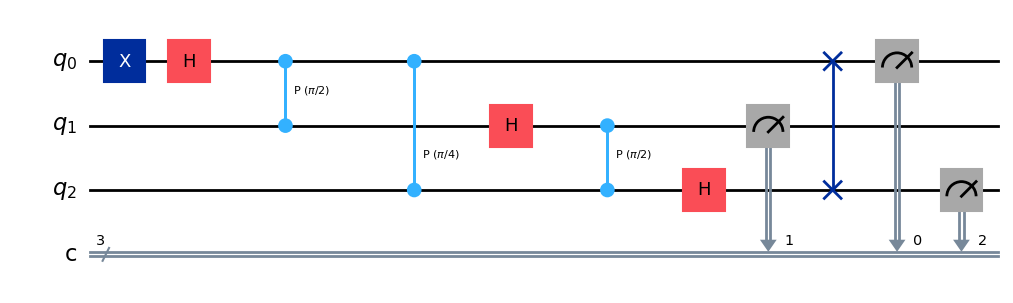

In [ ]:
qc = QuantumCircuit(3, 3)

# Initialize input state |001⟩
qc.x(0)

# Apply QFT
apply_qft(qc, 3)

# Measure the qubits
qc.measure([0, 1, 2], [0, 1, 2])

qc.draw('mpl')

{'101': 146, '001': 123, '010': 121, '000': 113, '100': 131, '011': 123, '111': 129, '110': 138}


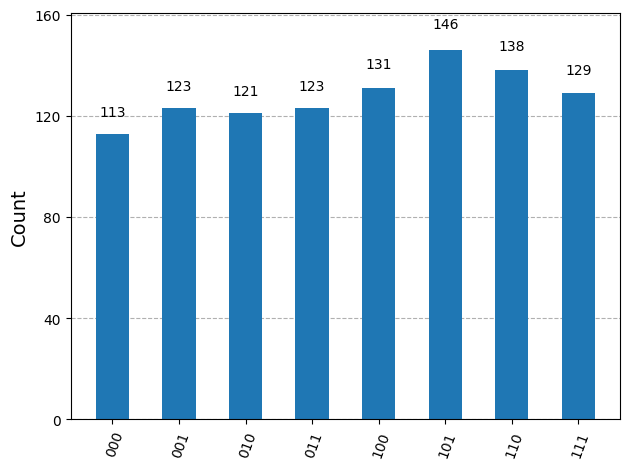

In [ ]:
backend = Aer.get_backend('qasm_simulator')
compiled = transpile(qc, backend)
job = backend.run(compiled, shots=1024)
result = job.result()
counts = result.get_counts()
print(counts)
plot_histogram(counts)